# Projeto 1: EDA para Previsão de Custos Médicos

**Objetivo:** entender o comportamento da variável `charges` e identificar quais atributos explicam melhor o custo do seguro médico antes de construir o baseline de regressão linear.

**Dataset:** `insurance.csv` (`Medical Cost Personal Datasets`, Kaggle)

**Perguntas que o EDA precisa responder:**
1. O dataset está íntegro para modelagem?
2. Como as variáveis numéricas e categóricas estão distribuídas?
3. A target `charges` é simétrica ou precisa de transformação?
4. Quais variáveis têm maior relação com `charges`?
5. Existem sinais de interação importante entre IMC e tabagismo?
6. Como os casos de alto custo se comportam?
7. Quais hipóteses seguem para o baseline linear do notebook `02_linear_regression.ipynb`?


## Roteiro da análise

1. Carga dos dados e visão geral.
2. Qualidade dos dados: tipos, nulos, duplicatas e valores inválidos.
3. Estatísticas descritivas e distribuição das variáveis.
4. Análise detalhada da variável-alvo `charges`.
5. Relações entre atributos e target, com correlação e testes estatísticos.
6. Interação entre IMC e tabagismo e perfil dos casos de alto custo.
7. Síntese executiva com implicações para o modelo baseline.


In [28]:
import warnings

import colorsys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")

def pastel_equal_lightness(n=8, lightness=0.78, saturation=0.42):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [colorsys.hls_to_rgb(float(h), lightness, saturation) for h in hues]

PASTEL_CYCLE = pastel_equal_lightness(n=8, lightness=0.78, saturation=0.42)

PALETTE_SMOKER = {"no": "#A9D6E5", "yes": "#F2B5D4"}
PALETTE_SEX = {"female": "#C7CEEA", "male": "#B5EAD7"}
PALETTE_REGION = {
    "southeast": "#FFD6A5",
    "southwest": "#FDFFB6",
    "northwest": "#CAE9FF",
    "northeast": "#E4C1F9",
}
NUMERIC_COLORS = {
    "age": "#A9D6E5",
    "bmi": "#F4C2C2",
    "children": "#B5EAD7",
    "charges": "#C7CEEA",
    "log_charges": "#FFD6A5",
}

sns.set_theme(style="whitegrid")
sns.set_palette(PASTEL_CYCLE)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_CYCLE)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [29]:
df = pd.read_csv("../data/insurance.csv").copy()
df["smoker_yes"] = (df["smoker"] == "yes").astype(int)
df["log_charges"] = np.log1p(df["charges"])
display(
    df.head().style.set_table_styles([
        {"selector": "table", "props": [("width", "100%"), ("display", "table")]},
    ])
)

,age,sex,bmi,children,smoker,region,charges,smoker_yes,log_charges
0,19,female,27.900000,0,yes,southwest,16884.924000,1,9.734236
1,18,male,33.770000,1,no,southeast,1725.552300,0,7.453882
2,28,male,33.000000,3,no,southeast,4449.462000,0,8.400763
3,33,male,22.705000,0,no,northwest,21984.470610,0,9.998137
4,32,male,28.880000,0,no,northwest,3866.855200,0,8.260455


## 1. Visão geral do dataset

Primeiro confirmamos tamanho, tipos e uma amostra dos dados. Isso evita começar a análise assumindo um schema incorreto.


In [30]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"\nColunas: {list(df.columns)}")
print("\nTipos das variáveis:")
print(df.dtypes)

Linhas: 1338
Colunas: 9

Colunas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'smoker_yes', 'log_charges']

Tipos das variáveis:
age              int64
sex             object
bmi            float64
children         int64
smoker          object
region          object
charges        float64
smoker_yes       int64
log_charges    float64
dtype: object


## 2. Qualidade dos dados

Aqui validamos se o dataset está pronto para uso: ausência de valores faltantes, duplicatas e valores impossíveis em variáveis que representam idade, IMC, número de filhos e custo.


In [31]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(by="missing", ascending=False)

duplicates = df.duplicated().sum()
invalid_rows = df.query("age <= 0 or bmi <= 0 or children < 0 or charges <= 0")

display(
    quality_report.style.set_table_styles([
        {"selector": "table", "props": [("width", "100%"), ("display", "table")]},
    ])
)
print(f"Duplicatas exatas: {duplicates}")
print(f"Registros com valores inválidos pelas regras de negócio: {invalid_rows.shape[0]}")
display(invalid_rows.head())

,dtype,missing,missing_pct,unique_values
age,int64,0,0.000000,47
sex,object,0,0.000000,2
bmi,float64,0,0.000000,548
children,int64,0,0.000000,6
smoker,object,0,0.000000,2
region,object,0,0.000000,4
charges,float64,0,0.000000,1337
smoker_yes,int64,0,0.000000,2
log_charges,float64,0,0.000000,1337


Duplicatas exatas: 1
Registros com valores inválidos pelas regras de negócio: 0


,age,sex,bmi,children,smoker,region,charges,smoker_yes,log_charges


In [32]:
# quantidade de pessoas/registros por número de filhos
df["children"].value_counts().sort_index()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [33]:
pd.crosstab(df["age"], df["children"])

children,0,1,2,3,4,5
age,,,,,,
18,51,9,6,2,1,0
19,50,11,5,1,0,1
20,17,6,3,1,0,2
21,16,5,5,1,1,0
22,18,4,2,4,0,0
23,13,6,5,4,0,0
24,23,1,1,2,1,0
25,12,6,4,3,2,1
26,10,9,7,1,1,0


## 3. Estatísticas descritivas

Resumo das variáveis numéricas e da frequência das variáveis categóricas para entender escala, dispersão e balanceamento dos grupos.


In [34]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

display(df[numeric_cols].describe().T)

for col in categorical_cols:
    freq = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq["pct"] = (freq["count"] / len(df) * 100).round(2)
    display(freq)

,count,mean,std,min,25%,50%,75%,max
age,"1,338.00",39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,"1,338.00",30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,"1,338.00",1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,"1,338.00","13,270.42","12,110.01","1,121.87","4,740.29","9,382.03","16,639.91","63,770.43"


,sex,count,pct
0,male,676,50.52
1,female,662,49.48


,smoker,count,pct
0,no,1064,79.52
1,yes,274,20.48


,region,count,pct
0,southeast,364,27.20
1,southwest,325,24.29
2,northwest,325,24.29
3,northeast,324,24.22


`age`: mediana 39, faixa 18–64, distribuição adulta bem ampla<br>
`bmi`: média 30.66 (acima de 30), indicando presença forte de sobrepeso/obesidade<br>
`children`: mediana 1 e Q3=2, então a maioria tem até 2 filhos<br>
`charges`: média (13.270) bem maior que a mediana (9.382) + máximo muito alto (63.770) e std grande, sinal de assimetria à direita e outliers<br>
`sex` está quase balanceado (50.5% vs 49.5%)<br>
`smoker` é desbalanceado (20.5% fumantes, 79.5% não fumantes)<br>
`region` está bem equilibrada (~24%–27% cada)<br>
`charges` é muito assimétrica, faz sentido testar log_charges e smoker é minoria, então vale manter split estratificado por smoker no treino/teste<br>

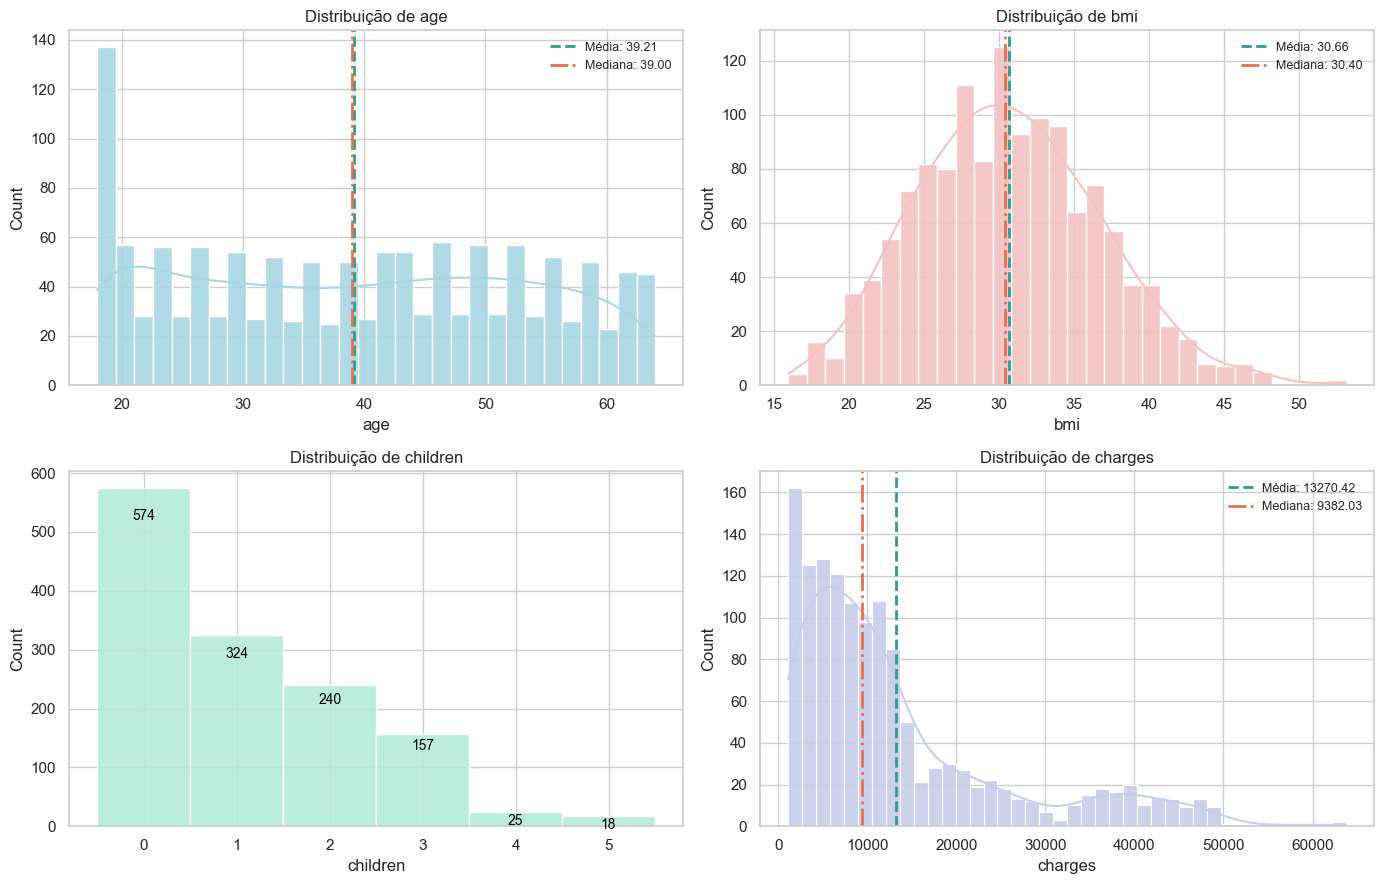

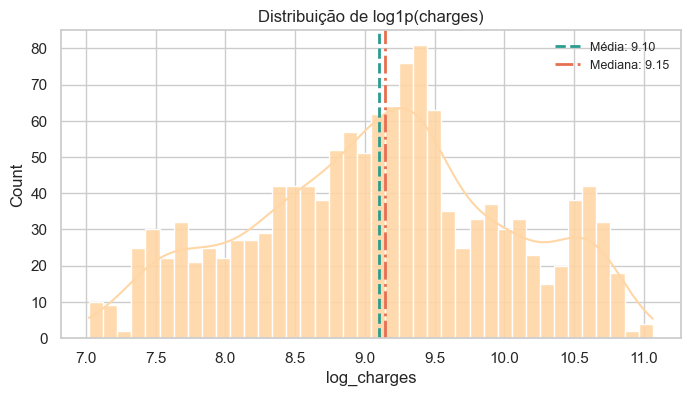

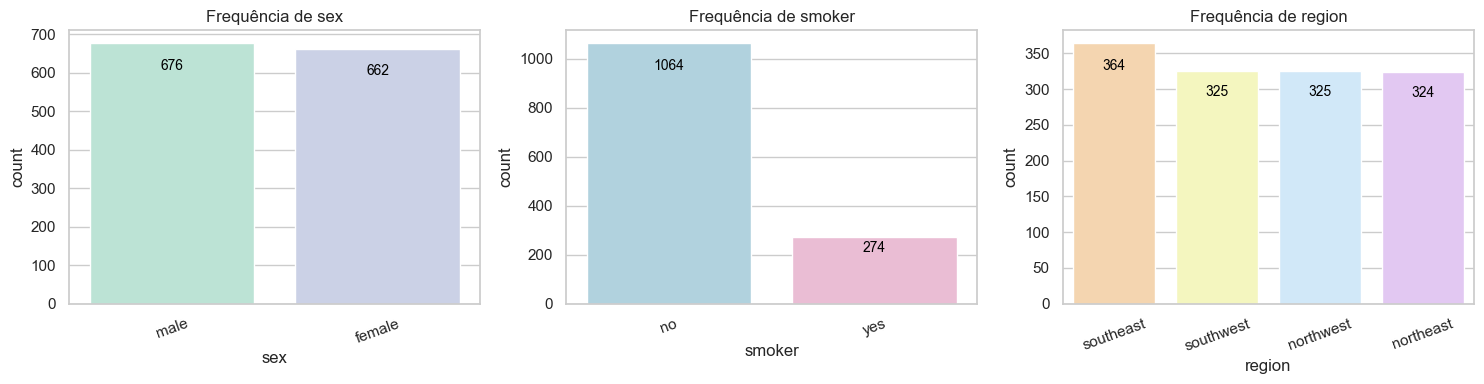

In [42]:
def pastel_equal_lightness(n=8, lightness=0.78, saturation=0.42):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [colorsys.hls_to_rgb(float(h), lightness, saturation) for h in hues]

PASTEL_CYCLE = pastel_equal_lightness(n=8, lightness=0.78, saturation=0.42)

PALETTE_SMOKER = {"no": "#A9D6E5", "yes": "#F2B5D4"}
PALETTE_SEX = {"female": "#C7CEEA", "male": "#B5EAD7"}
PALETTE_REGION = {
    "southeast": "#FFD6A5",
    "southwest": "#FDFFB6",
    "northwest": "#CAE9FF",
    "northeast": "#E4C1F9",
}
NUMERIC_COLORS = {
    "age": "#A9D6E5",
    "bmi": "#F4C2C2",
    "children": "#B5EAD7",
    "charges": "#C7CEEA",
    "log_charges": "#FFD6A5",
}

sns.set_theme(style="whitegrid")
sns.set_palette(PASTEL_CYCLE)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_CYCLE)
plt.rcParams["figure.figsize"] = (10, 5)

def add_count_labels_inside(ax, fontsize=10, color="black", frac=0.06):
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h) or h <= 0:
            continue
        y = h - max(h * frac, 4)
        ax.annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width() / 2, y),
            ha="center",
            va="top",
            fontsize=fontsize,
            color=color,
        )

def add_mean_median_lines(ax, s, mean_color="#2A9D8F", median_color="#E76F51"):
    mean_v = s.mean()
    median_v = s.median()
    ax.axvline(mean_v, color=mean_color, linestyle="--", linewidth=2, label=f"Média: {mean_v:.2f}")
    ax.axvline(median_v, color=median_color, linestyle="-.", linewidth=2, label=f"Mediana: {median_v:.2f}")
    ax.legend(frameon=False, fontsize=9)

df = pd.read_csv("../data/insurance.csv").copy()
df["smoker_yes"] = (df["smoker"] == "yes").astype(int)
df["log_charges"] = np.log1p(df["charges"])

numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    if col == "children":
        sns.histplot(
            df[col],
            discrete=True,
            kde=False,
            color=NUMERIC_COLORS[col],
            edgecolor="white",
            alpha=0.9,
            ax=ax,
        )
        add_count_labels_inside(ax)
    else:
        sns.histplot(
            df[col],
            bins=30 if col != "charges" else 40,
            kde=True,
            color=NUMERIC_COLORS[col],
            edgecolor="white",
            alpha=0.9,
            ax=ax,
        )
        add_mean_median_lines(ax, df[col])

    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    df["log_charges"],
    bins=40,
    kde=True,
    color=NUMERIC_COLORS["log_charges"],
    edgecolor="white",
    alpha=0.9,
)
add_mean_median_lines(plt.gca(), df["log_charges"])
plt.title("Distribuição de log1p(charges)")
plt.xlabel("log_charges")
plt.show()

palette_map = {
    "sex": PALETTE_SEX,
    "smoker": PALETTE_SMOKER,
    "region": PALETTE_REGION,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(
        data=df,
        x=col,
        order=order,
        hue=col,
        palette=palette_map[col],
        legend=False,
        ax=ax,
    )
    add_count_labels_inside(ax)
    ax.set_title(f"Frequência de {col}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. Foco na variável-alvo `charges`

Como o projeto é de regressão, a target merece uma inspeção separada. Avaliamos assimetria, presença de outliers e o efeito de aplicar `log1p(charges)`.


,metric,value
0,mean,"13,270.42"
1,median,"9,382.03"
2,std,"12,110.01"
3,cv_pct,91.26
4,skew(charges),1.52
5,kurtosis(charges),1.61
6,skew(log1p(charges)),-0.09
7,q1,"4,740.29"
8,q3,"16,639.91"
9,iqr,"11,899.63"


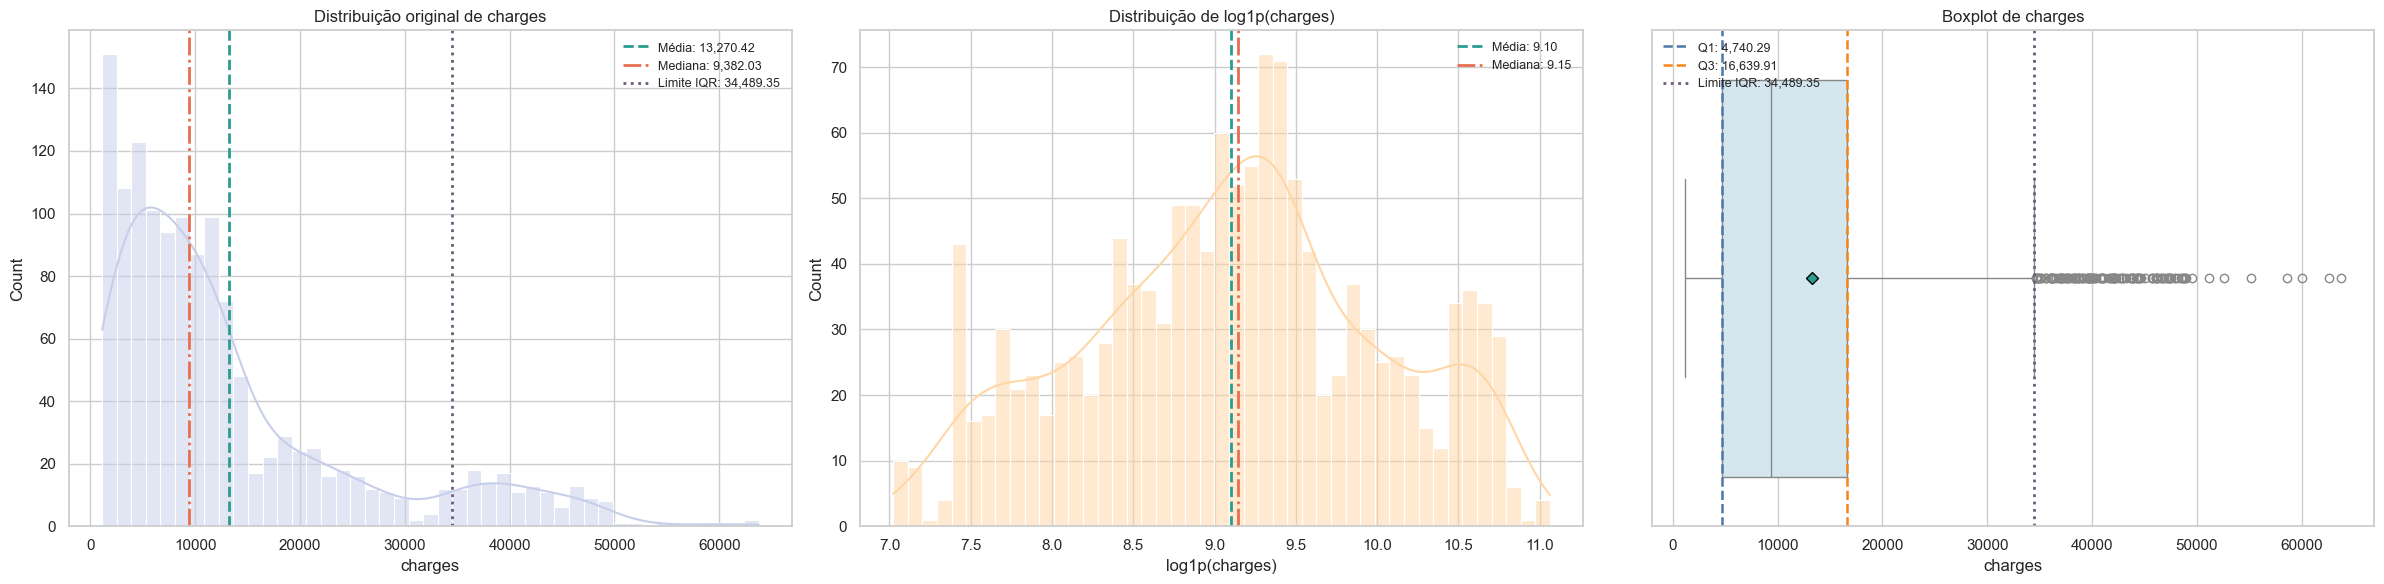

In [45]:
if "log_charges" not in df.columns:
    df["log_charges"] = np.log1p(df["charges"])

q1, q3 = df["charges"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

df["is_high_cost"] = df["charges"] > upper_limit

mean_raw = df["charges"].mean()
median_raw = df["charges"].median()
std_raw = df["charges"].std()

mean_log = df["log_charges"].mean()
median_log = df["log_charges"].median()

target_profile = pd.DataFrame({
    "metric": [
        "mean",
        "median",
        "std",
        "cv_pct",
        "skew(charges)",
        "kurtosis(charges)",
        "skew(log1p(charges))",
        "q1",
        "q3",
        "iqr",
        "p90",
        "p95",
        "outliers_acima_limite_iqr",
        "pct_outliers_iqr",
        "limite_inferior_iqr",
        "limite_superior_iqr",
    ],
    "value": [
        mean_raw,
        median_raw,
        std_raw,
        (std_raw / mean_raw) * 100,
        df["charges"].skew(),
        df["charges"].kurt(),
        df["log_charges"].skew(),
        q1,
        q3,
        iqr,
        df["charges"].quantile(0.90),
        df["charges"].quantile(0.95),
        df["is_high_cost"].sum(),
        df["is_high_cost"].mean() * 100,
        lower_limit,
        upper_limit,
    ],
})

target_profile["value"] = target_profile["value"].round(2)
display(target_profile)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# 1) charges original
sns.histplot(
    df["charges"],
    bins=45,
    kde=True,
    color=NUMERIC_COLORS["charges"],
    edgecolor="white",
    ax=axes[0]
)
axes[0].axvline(mean_raw, color="#2A9D8F", linestyle="--", linewidth=2, label=f"Média: {mean_raw:,.2f}")
axes[0].axvline(median_raw, color="#E76F51", linestyle="-.", linewidth=2, label=f"Mediana: {median_raw:,.2f}")
axes[0].axvline(upper_limit, color="#6D597A", linestyle=":", linewidth=2, label=f"Limite IQR: {upper_limit:,.2f}")
axes[0].set_title("Distribuição original de charges")
axes[0].set_xlabel("charges")
axes[0].legend(frameon=False, fontsize=9)

# 2) log1p(charges)
sns.histplot(
    df["log_charges"],
    bins=45,
    kde=True,
    color=NUMERIC_COLORS["log_charges"],
    edgecolor="white",
    ax=axes[1]
)
axes[1].axvline(mean_log, color="#2A9D8F", linestyle="--", linewidth=2, label=f"Média: {mean_log:.2f}")
axes[1].axvline(median_log, color="#E76F51", linestyle="-.", linewidth=2, label=f"Mediana: {median_log:.2f}")
axes[1].set_title("Distribuição de log1p(charges)")
axes[1].set_xlabel("log1p(charges)")
axes[1].legend(frameon=False, fontsize=9)

# 3) boxplot charges
sns.boxplot(
    x=df["charges"],
    ax=axes[2],
    color="#D0E8F2",
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "#2A9D8F", "markeredgecolor": "black", "markersize": 6}
)
axes[2].axvline(q1, color="#4C78A8", linestyle="--", linewidth=1.8, label=f"Q1: {q1:,.2f}")
axes[2].axvline(q3, color="#F58518", linestyle="--", linewidth=1.8, label=f"Q3: {q3:,.2f}")
axes[2].axvline(upper_limit, color="#6D597A", linestyle=":", linewidth=2, label=f"Limite IQR: {upper_limit:,.2f}")
axes[2].set_title("Boxplot de charges")
axes[2].set_xlabel("charges")
axes[2].legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

`mean` = 13.270 e median = 9.382: média bem maior que mediana, sinal clássico de cauda à direita<br>
`std` = 12.110: alta dispersão dos custos<br>
`skew(charges)` = 1.52: assimetria positiva forte (distribuição “puxada” para valores altos)<br>
`skew(log1p(charges))` = -0.09: após log, a distribuição fica quase simétrica<br>
`limite_superior_iqr` = 34.489: acima disso o método IQR marca como outlier<br>
`outliers_acima_limite_iqr` = 139 (10.39%): proporção relevante de custos muito altos<br>
charges original tem cauda longa e muitos extremos<br>
outliers podem representar casos reais caros (especialmente fumantes). comparar de modelos (com e sem log) para decidir

## 5. Relação das variáveis com a target

Nesta etapa medimos associação linear entre os atributos e `charges`.

- Para `age`, `bmi` e `children`, usamos correlação de Pearson.
- Para `smoker`, usamos `smoker_yes` (0/1). Nesse caso, a correlação de Pearson equivale à correlação ponto-bisserial.
- Também comparamos a mesma relação com `log1p(charges)`, porque o baseline testará a target nas duas escalas.
- O **p-valor** ajuda a verificar se a associação observada é estatisticamente diferente de zero.


,feature,pearson_r_charges,p_value_charges,pearson_r_log_charges,p_value_log_charges
3,smoker_yes,0.79,0.00,0.67,0.00
0,age,0.30,0.00,0.53,0.00
1,bmi,0.20,0.00,0.13,0.00
2,children,0.07,0.01,0.16,0.00


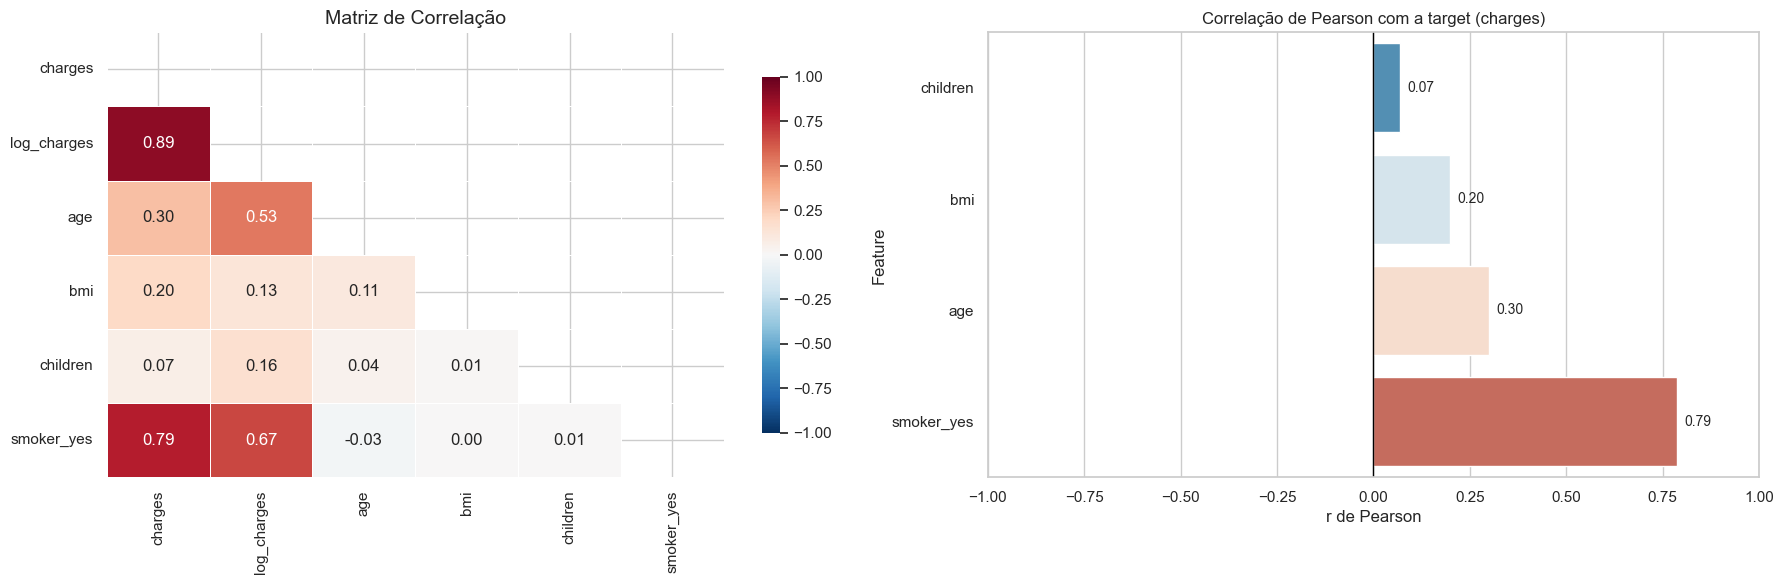

In [59]:
# garante coluna numérica para smoker
if "smoker_yes" not in df.columns:
    df["smoker_yes"] = (df["smoker"] == "yes").astype(int)

# tabela de associação
association_rows = []
for col in ["age", "bmi", "children", "smoker_yes"]:
    corr_raw, p_raw = stats.pearsonr(df[col], df["charges"])
    corr_log, p_log = stats.pearsonr(df[col], df["log_charges"])
    association_rows.append({
        "feature": col,
        "pearson_r_charges": corr_raw,
        "p_value_charges": p_raw,
        "pearson_r_log_charges": corr_log,
        "p_value_log_charges": p_log
    })

association_table = (
    pd.DataFrame(association_rows)
    .sort_values(by="pearson_r_charges", ascending=False)
)
display(association_table)

# dados para os gráficos
corr_matrix = df[["charges", "log_charges", "age", "bmi", "children", "smoker_yes"]].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

target = "charges"
features = ["age", "bmi", "children", "smoker_yes"]

rows = []
for f in features:
    r, p = stats.pearsonr(df[f], df[target])
    rows.append({"feature": f, "pearson_r": r, "p_value": p})

corr_target = pd.DataFrame(rows).sort_values("pearson_r", ascending=True)

# gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (1) heatmap triangular
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title("Matriz de Correlação", fontsize=14)
axes[0].tick_params(axis="x", rotation=90)
axes[0].tick_params(axis="y", rotation=0)

# correlação com target
sns.barplot(
    data=corr_target,
    x="pearson_r",
    y="feature",
    palette="RdBu_r",
    ax=axes[1]
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(-1, 1)
axes[1].set_title("Correlação de Pearson com a target (charges)")
axes[1].set_xlabel("r de Pearson")
axes[1].set_ylabel("Feature")

for i, row in corr_target.reset_index(drop=True).iterrows():
    x = row["pearson_r"]
    axes[1].text(
        x + (0.02 if x >= 0 else -0.02),
        i,
        f"{x:.2f}",
        va="center",
        ha="left" if x >= 0 else "right",
        fontsize=10
    )

plt.tight_layout()
plt.show()

`smoker_yes` (r=0.79 com charges) é o preditor mais forte<br>
`age` (r=0.30) tem efeito moderado<br>
`bmi` (r=0.20) tem efeito fraco<br>
`children` (r=0.07) é efeito muito fraco (mesmo com p baixo, impacto pequeno)<br>
com `log_charges`, age sobe para r=0.53 e children para r=0.16, sugerindo que a transformação log melhora parte da estrutura linear<br>
entre preditores, as correlações são baixas (ex: age vs bmi ~0.11, age vs smoker_yes ~-0.03), o que é bom para multicolinearidade no baseline<br>
baseline faz sentido com smoker_yes + age + bmi<br>
children pode entrar como teste, mas expectativa de ganho é pequena<br>

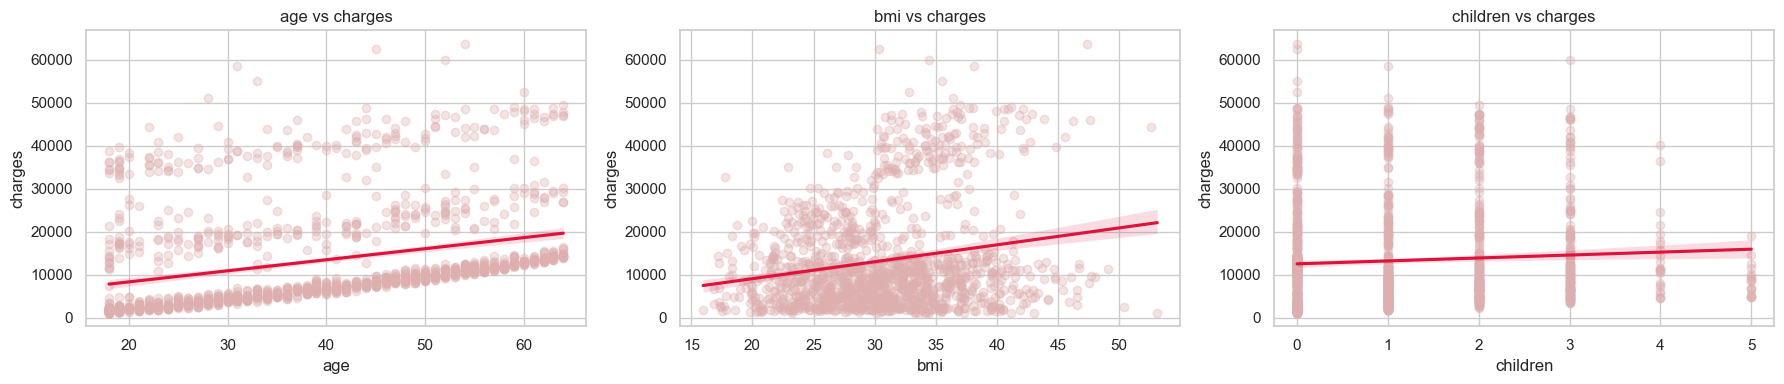

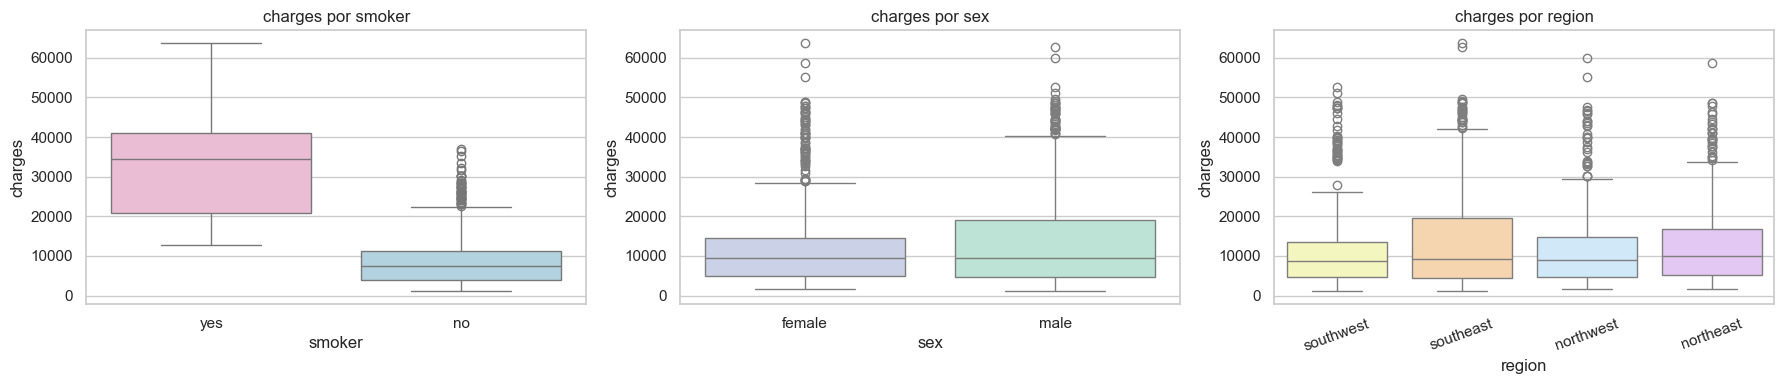

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ["age", "bmi", "children"]):
    sns.regplot(
        data=df,
        x=col,
        y="charges",
        scatter_kws={"alpha": 0.35},
        line_kws={"color": "crimson"},
        ax=ax
    )
    ax.set_title(f"{col} vs charges")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette=PALETTE_SMOKER, legend=False, ax=axes[0])
axes[0].set_title("charges por smoker")

sns.boxplot(data=df, x="sex", y="charges", hue="sex", palette=PALETTE_SEX, legend=False, ax=axes[1])
axes[1].set_title("charges por sex")

sns.boxplot(data=df, x="region", y="charges", hue="region", palette=PALETTE_REGION, legend=False, ax=axes[2])
axes[2].set_title("charges por region")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

`age` vs `charges`: tendência positiva clara. em média, custo sobe com idade, mas com bastante dispersão<br>
`bmi` vs `charges`: tendência positiva mais fraca/moderada e bem espalhada. sozinho explica pouco<br>
`children` vs `charges`: linha quase plana; efeito linear fraco<br>
`charges` por `smoker`: fumantes têm mediana e faixa inteira de custos muito acima dos não fumantes<br>
`charges` por `sex`: distribuições parecidas; diferença pequena<br>
`charges` por `region`: distribuições relativamente próximas; sem separação forte entre regiões<br>

### Evidência por grupos categóricos

Além da correlação, vale comparar a distribuição de `charges` entre os principais grupos. Isso ajuda a justificar por que `smoker` entra no baseline e por que `sex` e `region` podem ficar para uma segunda iteração.


,count,mean,median,std
smoker,,,,
no,1064,"8,434.27","7,345.41","5,993.78"
yes,274,"32,050.23","34,456.35","11,541.55"


,count,mean,median,std
sex,,,,
female,662,"12,569.58","9,412.96","11,128.70"
male,676,"13,956.75","9,369.62","12,971.03"


,count,mean,median,std
region,,,,
northeast,324,"13,406.38","10,057.65","11,255.80"
northwest,325,"12,417.58","8,965.80","11,072.28"
southeast,364,"14,735.41","9,294.13","13,971.10"
southwest,325,"12,346.94","8,798.59","11,557.18"


,comparison,test,statistic,p_value
0,smoker=yes vs smoker=no,Welch t-test,32.75,0.00
1,sex=female vs sex=male,Welch t-test,-2.10,0.04
2,region groups,Kruskal-Wallis,4.73,0.19


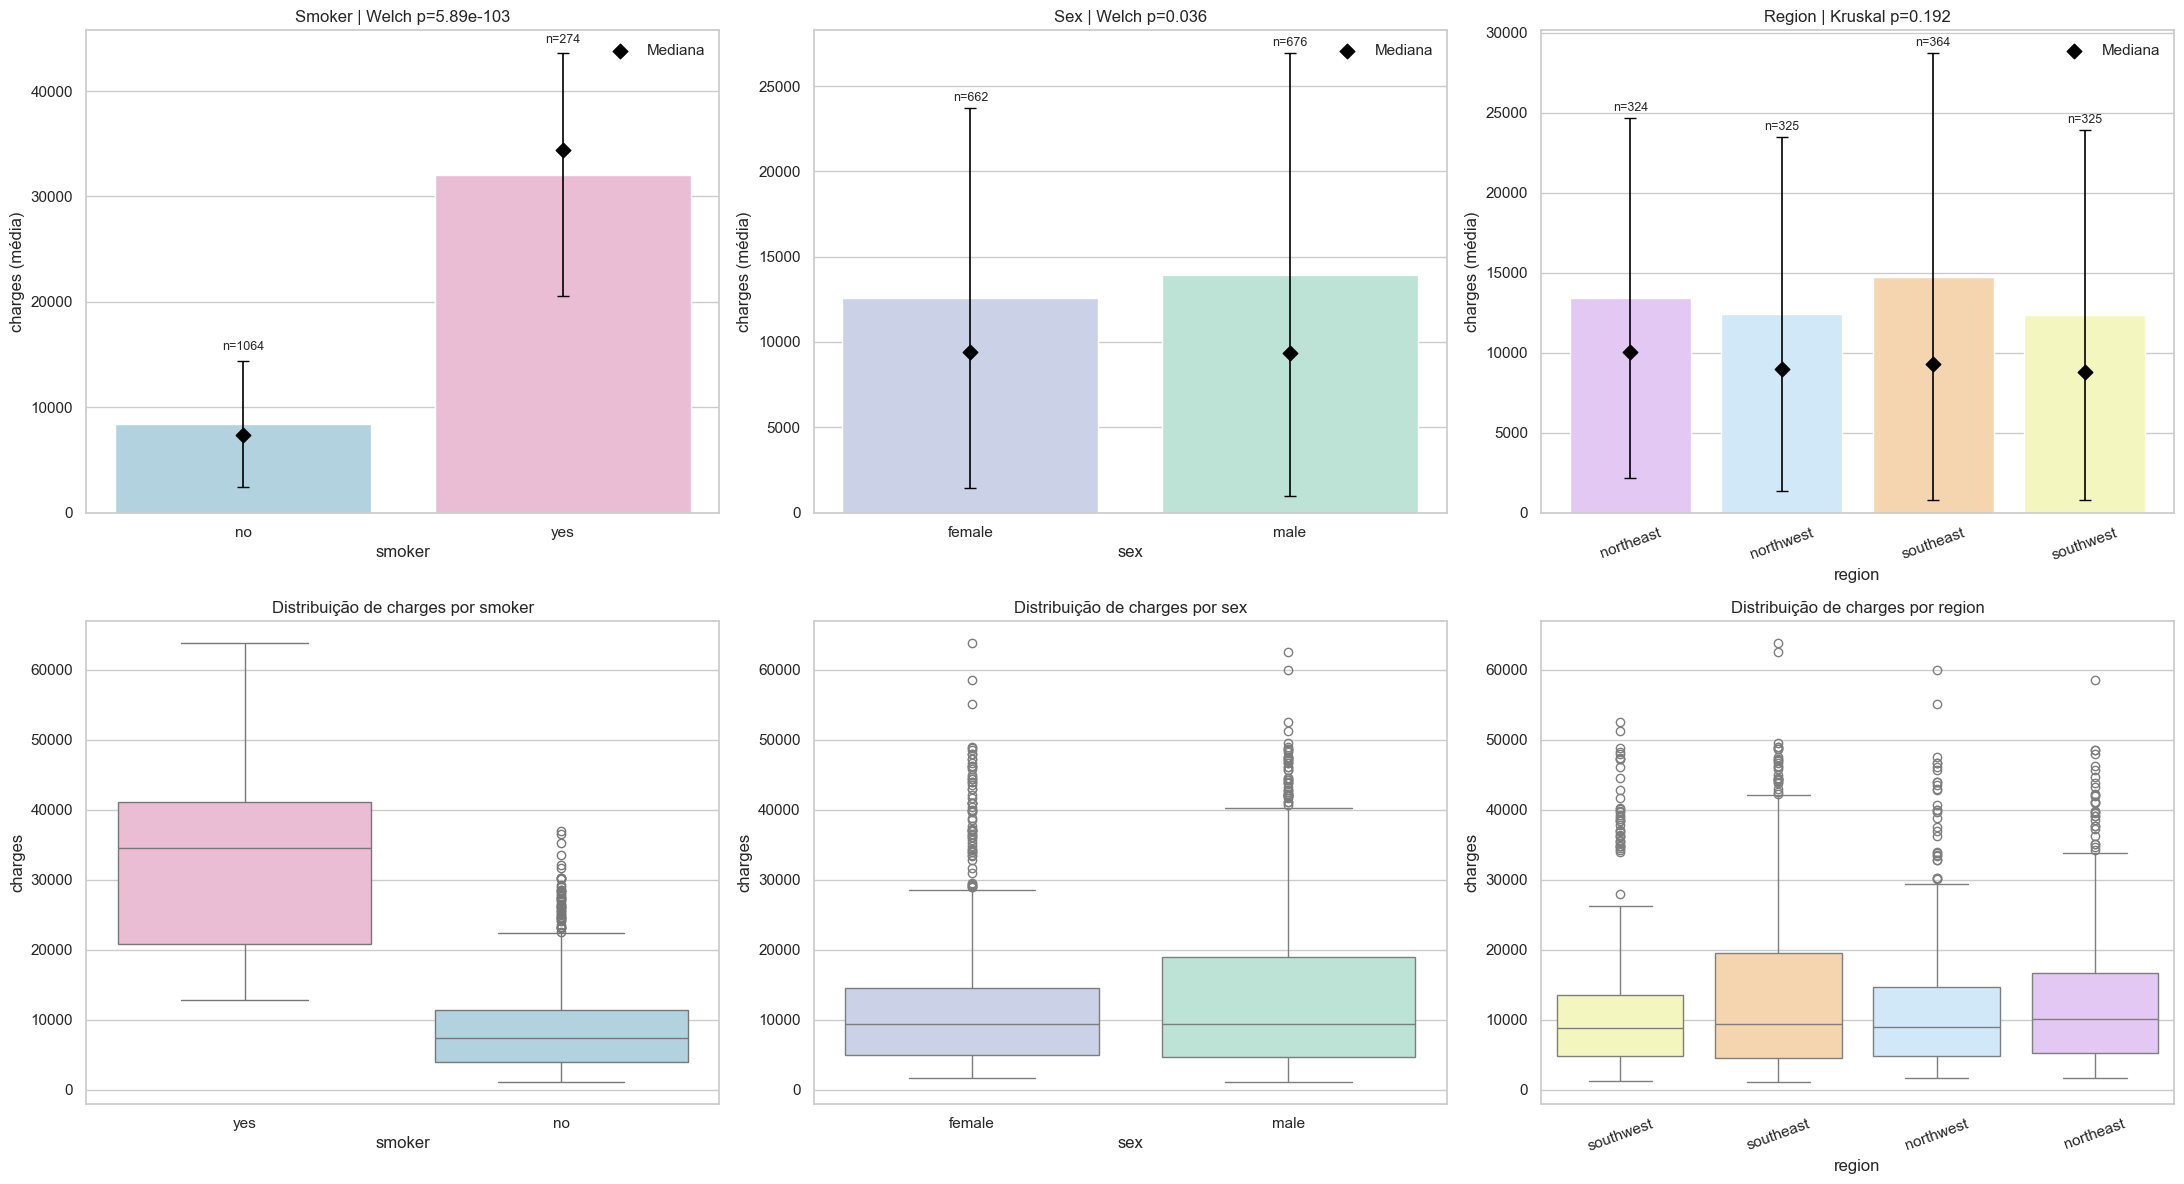

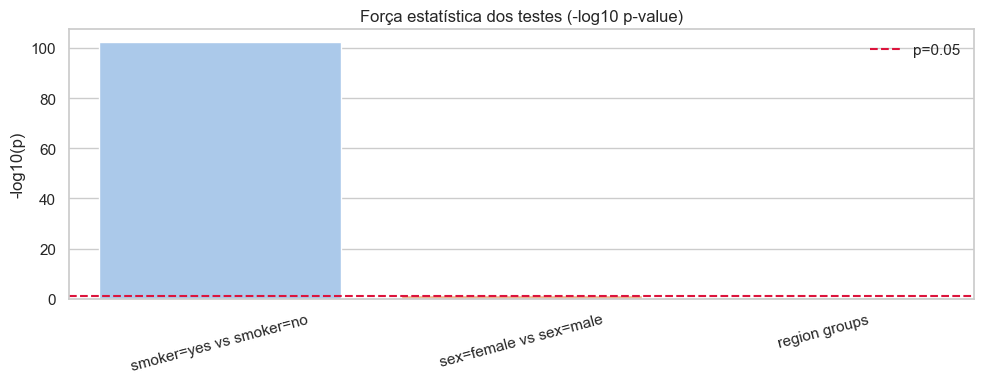

In [70]:
# resumos e testes
smoker_summary = df.groupby("smoker")["charges"].agg(["count", "mean", "median", "std"]).round(2)
sex_summary = df.groupby("sex")["charges"].agg(["count", "mean", "median", "std"]).round(2)
region_summary = df.groupby("region")["charges"].agg(["count", "mean", "median", "std"]).round(2)

welch_smoker = stats.ttest_ind(
    df.loc[df["smoker"] == "yes", "charges"],
    df.loc[df["smoker"] == "no", "charges"],
    equal_var=False
)

welch_sex = stats.ttest_ind(
    df.loc[df["sex"] == "female", "charges"],
    df.loc[df["sex"] == "male", "charges"],
    equal_var=False
)

kruskal_region = stats.kruskal(*[g["charges"].values for _, g in df.groupby("region")])

categorical_tests = pd.DataFrame([
    {"comparison": "smoker=yes vs smoker=no", "test": "Welch t-test", "statistic": welch_smoker.statistic, "p_value": welch_smoker.pvalue},
    {"comparison": "sex=female vs sex=male", "test": "Welch t-test", "statistic": welch_sex.statistic, "p_value": welch_sex.pvalue},
    {"comparison": "region groups", "test": "Kruskal-Wallis", "statistic": kruskal_region.statistic, "p_value": kruskal_region.pvalue},
])

display(smoker_summary)
display(sex_summary)
display(region_summary)
display(categorical_tests)

# paletas
PALETTE_SMOKER = {"no": "#A9D6E5", "yes": "#F2B5D4"}
PALETTE_SEX = {"female": "#C7CEEA", "male": "#B5EAD7"}
PALETTE_REGION = {"southeast": "#FFD6A5", "southwest": "#FDFFB6", "northwest": "#CAE9FF", "northeast": "#E4C1F9"}

# gráficos: médias/medianas + distribuição
def plot_mean_std_median(ax, summary_df, group_col, palette, title):
    plot_df = summary_df.reset_index().rename(columns={summary_df.index.name: group_col})
    order = plot_df[group_col].tolist()

    sns.barplot(
        data=plot_df, x=group_col, y="mean",
        order=order, palette=palette, ax=ax, edgecolor="white"
    )

    x = np.arange(len(plot_df))
    ax.errorbar(
        x=x, y=plot_df["mean"], yerr=plot_df["std"],
        fmt="none", c="black", capsize=4, linewidth=1.2
    )

    ax.scatter(x, plot_df["median"], marker="D", s=55, color="black", label="Mediana", zorder=3)

    offset = max(plot_df["mean"].max() * 0.03, 300)
    for i, row in plot_df.iterrows():
        ax.text(i, row["mean"] + row["std"] + offset, f"n={int(row['count'])}", ha="center", fontsize=9)

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel("charges (média)")
    ax.legend(frameon=False)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# linha 1: média + desvio + mediana
plot_mean_std_median(
    axes[0, 0], smoker_summary, "smoker", PALETTE_SMOKER,
    f"Smoker | Welch p={welch_smoker.pvalue:.2e}"
)
plot_mean_std_median(
    axes[0, 1], sex_summary, "sex", PALETTE_SEX,
    f"Sex | Welch p={welch_sex.pvalue:.3f}"
)
plot_mean_std_median(
    axes[0, 2], region_summary, "region", PALETTE_REGION,
    f"Region | Kruskal p={kruskal_region.pvalue:.3f}"
)
axes[0, 2].tick_params(axis="x", rotation=20)

# linha 2: boxplots (distribuição)
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette=PALETTE_SMOKER, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribuição de charges por smoker")

sns.boxplot(data=df, x="sex", y="charges", hue="sex", palette=PALETTE_SEX, legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribuição de charges por sex")

sns.boxplot(data=df, x="region", y="charges", hue="region", palette=PALETTE_REGION, legend=False, ax=axes[1, 2])
axes[1, 2].set_title("Distribuição de charges por region")
axes[1, 2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# gráfico só dos p-values
tests_plot = categorical_tests.copy()
tests_plot["neg_log10_p"] = -np.log10(tests_plot["p_value"].clip(lower=1e-300))

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=tests_plot, x="comparison", y="neg_log10_p", palette="pastel")
ax.axhline(-np.log10(0.05), color="crimson", linestyle="--", linewidth=1.5, label="p=0.05")
ax.set_title("Força estatística dos testes (-log10 p-value)")
ax.set_xlabel("")
ax.set_ylabel("-log10(p)")
ax.tick_params(axis="x", rotation=15)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

`smoker` é o maior driver de custo: <br>
- média: 32.050 (fumante) vs 8.434 (não fumante)<br>
- mediana também muito maior (34.456 vs 7.345)<br>
- welch p-value extremamente baixo (~5.9e-103)<br>

`sex` tem efeito fraco
- médias diferentes (13.957 vs 12.570), mas medianas quase iguais<br>
- p-value ~0.036: significante estatisticamente, mas efeito prático pequeno<br>

`region` não mostra diferença forte<br>
- médias variam um pouco (southeast maior), mas dispersão é alta e boxes se sobrepõem<br>
- kruskal p-value ~0.192 (> 0.05): sem evidência estatística de diferença relevante entre regiões<br>
<br>
a variabilidade é alta em todos os grupos (std grande e muitos outliers), então a média isolada pode enganar. mediana + boxplot são melhores para interpretação<br>
<br>

## 6. Hipótese de interação: IMC x tabagismo

Uma suspeita frequente nesse dataset é que IMC tenha efeito mais forte entre fumantes. Vamos medir isso com uma feature de interação e com cortes por faixa de IMC.


Correlação entre bmi_x_smoker e charges: 0.845
p-valor da interação: 0.000e+00


mean    median  count
bmi_bin    smoker                           
baixo peso no      5,485.06  4,249.32     16
           yes    18,809.82 15,006.58      5
normal     no      7,734.65  6,669.48    176
           yes    19,942.22 19,479.90     50
sobrepeso  no      8,226.09  7,046.72    311
           yes    22,491.18 21,348.71     75
obesidade  no      8,853.28  8,083.92    561
           yes    41,692.81 40,918.31    144

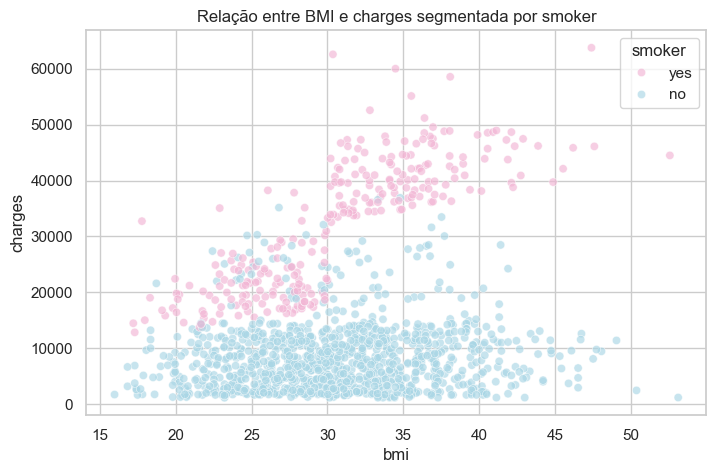

In [61]:
df["bmi_x_smoker"] = df["bmi"] * df["smoker_yes"]
df["bmi_bin"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, df["bmi"].max() + 1],
    labels=["baixo peso", "normal", "sobrepeso", "obesidade"],
    include_lowest=True
)

interaction_corr, interaction_p = stats.pearsonr(df["bmi_x_smoker"], df["charges"])
print(f"Correlação entre bmi_x_smoker e charges: {interaction_corr:.3f}")
print(f"p-valor da interação: {interaction_p:.3e}")

bmi_smoker_summary = df.groupby(["bmi_bin", "smoker"], observed=False)["charges"].agg(["mean", "median", "count"]).round(2)
display(bmi_smoker_summary)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette=PALETTE_SMOKER, alpha=0.65)
plt.title("Relação entre BMI e charges segmentada por smoker")
plt.show()

corr = 0.845 com charges é muito alta, sinal forte de interação entre IMC e tabagismo<br>
p-value ~ 0 indica que essa associação não é aleatória<br>
dentro de cada faixa de IMC, fumantes sempre têm custo muito maior<br>


## 7. Perfil dos casos de alto custo

Como `charges` tem cauda longa, vale entender quem são os registros acima do limite do boxplot. Isso ajuda a decidir se estamos diante de ruído ou de um padrão importante do negócio.


age                bmi              children              \
             count  mean median count  mean median    count mean median   
is_high_cost                                                              
False         1199 38.99  39.00  1199 30.10  29.74     1199 1.08   1.00   
True           139 41.08  43.00   139 35.56  35.20      139 1.19   1.00   

             charges                      
               count      mean    median  
is_high_cost                              
False           1199  9,927.75  8,410.05  
True             139 42,103.95 40,974.16

smoker,no,yes
is_high_cost,,
False,88.49,11.51
True,2.16,97.84


region,northeast,northwest,southeast,southwest
is_high_cost,,,,
False,24.69,25.44,25.60,24.27
True,20.14,14.39,41.01,24.46


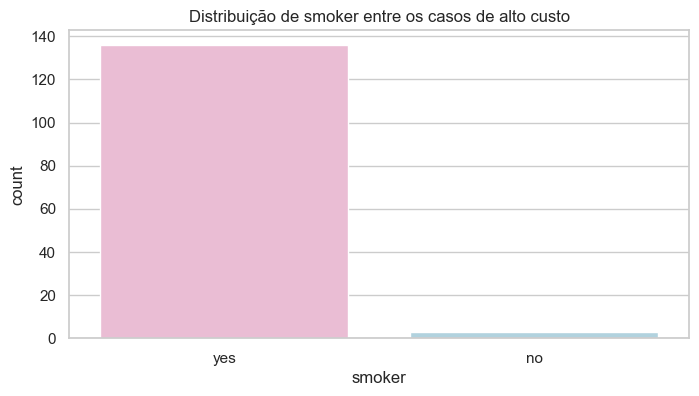

In [71]:
high_cost_numeric = (
    df.groupby("is_high_cost")[["age", "bmi", "children", "charges"]]
    .agg(["count", "mean", "median"])
    .round(2)
)

high_cost_categorical = pd.crosstab(
    df["is_high_cost"],
    df["smoker"],
    normalize="index"
).mul(100).round(2)

high_cost_region = pd.crosstab(
    df["is_high_cost"],
    df["region"],
    normalize="index"
).mul(100).round(2)

display(high_cost_numeric)
display(high_cost_categorical)
display(high_cost_region)

plt.figure(figsize=(8, 4))
sns.countplot(data=df[df["is_high_cost"]], x="smoker", hue="smoker", palette=PALETTE_SMOKER, legend=False)
plt.title("Distribuição de smoker entre os casos de alto custo")
plt.show()

## 8. Síntese para o baseline de regressão linear

O objetivo aqui não é fechar o modelo, e sim transformar a exploração em decisões práticas para o notebook seguinte.


In [ ]:
baseline_recommendations = pd.DataFrame([
    {
        "item": "Qualidade do dado",
        "evidence": "Não há nulos nem valores inválidos, mas existe 1 duplicata exata.",
        "implication": "Remover duplicata no notebook de modelagem para trabalhar com base limpa."
    },
    {
        "item": "Target",
        "evidence": "charges é assimétrica à direita e possui outliers relevantes; log1p reduz fortemente a assimetria.",
        "implication": "Comparar baseline em charges e em log1p(charges)."
    },
    {
        "item": "age",
        "evidence": "Correlação positiva moderada com charges e com log_charges.",
        "implication": "Manter no modelo baseline."
    },
    {
        "item": "bmi",
        "evidence": "Correlação positiva fraca isoladamente, mas maior efeito quando combinado com smoker.",
        "implication": "Usar no baseline simples e considerar interação em versões futuras."
    },
    {
        "item": "smoker",
        "evidence": "Maior associação com charges, diferença forte entre grupos e p-valor extremamente baixo.",
        "implication": "Variável essencial no baseline."
    },
    {
        "item": "sex / region / children",
        "evidence": "Sinais mais fracos ou menos relevantes do que age, bmi e smoker para a primeira iteração.",
        "implication": "Deixar fora do baseline simples e testar depois como expansão do modelo."
    }
])

display(baseline_recommendations)

### Conclusões do EDA

- O dataset está praticamente limpo para a primeira versão do modelo: sem nulos, sem valores inválidos e com apenas 1 duplicata exata.
- `charges` apresenta cauda longa e outliers; por isso, avaliar `log1p(charges)` faz sentido para melhorar a aderência às premissas de um modelo linear.
- `smoker` é o principal preditor do custo médico e deve estar no baseline obrigatoriamente.
- `age` contribui com sinal positivo consistente.
- `bmi` sozinho explica menos, mas ganha relevância quando combinado com tabagismo.
- `sex` e `region` têm utilidade exploratória, mas ficam atrás de `age`, `bmi` e `smoker` como explicadores principais do custo.
- Os casos de alto custo não parecem ruído aleatório: eles se concentram mais em fumantes e em perfis com IMC mais alto.
- A partir deste EDA, o baseline mais coerente é começar com `age`, `bmi` e `smoker`, comparando desempenho na escala original e na escala logarítmica.
